In [1]:
import sys
import os
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import random

sys.path.append(os.path.join(os.getcwd(), ".."))
from models.SAC import SoftActorCritic
from models.experiment_model import StateSpaceModel

In [2]:
MAX_EPISODE = 50000
MAX_TIME_PER_EPISODE = 60*15
DT = 3
MAX_ITER_PER_EPISODE = int(MAX_TIME_PER_EPISODE/DT) # This should be 300

In [2]:
from collections import namedtuple

MAX_H = 8.5
with open(r"..\parameters\state_space_param.pickle", "rb") as f:
    statespaceparam = pickle.load(f)
A, B, C, D = statespaceparam['A'], statespaceparam['B'], statespaceparam['C'], statespaceparam['D']

transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'terminal_flag'))

class environment():
    def __init__(self):
        dt = 3
        A_ = A.astype(float)
        B_ = B.astype(float).reshape(2, 1)
        I = np.eye(2)
        A2 = A_ @ A_
        A3 = A2 @ A_
        A4 = A3 @ A_
        self._Ad = I + dt*A_ + (dt**2/2)*A2 + (dt**3/6)*A3 + (dt**4/24)*A4
        self._Bd = (dt*I + (dt**2/2)*A_ + (dt**3/6)*A2 + (dt**4/24)*A3 + (dt**5/120)*A4) @ B_

    def reset(self):
        self.sp = random.random()
        self.xk = np.random.rand(2)
        return [self.xk[1].item(), self.sp]

    def reward_calculation(self):
        terminated = False

        error = abs(self.xk[1] - self.sp).item()
        reward = -error * MAX_H

        if any(self.xk >= 1.0):
            terminated = True
            reward = -100

        return reward, terminated

    def step(self, action, dt=3):
        xk = self.xk.reshape(2, 1) * MAX_H
        xk1 = self._Ad @ xk + self._Bd * action
        self.xk = xk1.flatten() / MAX_H
        next_state = (self.xk[1].item(), self.sp)
        reward, terminated = self.reward_calculation()
        return next_state, reward, terminated

In [3]:
with open(r"..\config\SAC.yaml") as f:
    config = yaml.safe_load(f)

v_net_arg = config["v_net_arg"]
q_net_arg = config["q_net_arg"]
actor_net_arg = config["actor_net_arg"]

replay_capa = config["replay_capa"]

In [5]:
agent = SoftActorCritic(v_net_arg, q_net_arg, actor_net_arg, replay_capa)
print(agent.actor, agent.critic_1, agent.value)

ActorNetwork(
  (backbone): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu_net): Linear(in_features=128, out_features=1, bias=True)
  (log_std_net): Linear(in_features=128, out_features=1, bias=True)
) QNetwork(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
) VNetwork(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [8]:
class eval_environment():
    def __init__(self):
        dt = 3
        A_ = A.astype(float)
        B_ = B.astype(float).reshape(2, 1)
        I = np.eye(2)
        A2 = A_ @ A_
        A3 = A2 @ A_
        A4 = A3 @ A_
        self._Ad = I + dt*A_ + (dt**2/2)*A2 + (dt**3/6)*A3 + (dt**4/24)*A4
        self._Bd = (dt*I + (dt**2/2)*A_ + (dt**3/6)*A2 + (dt**4/24)*A3 + (dt**5/120)*A4) @ B_

    def reset(self): # made the initial state and set point as fixed
        self.sp = 0.5
        self.xk = np.array([0, 0])
        return [self.xk[1].item(), self.sp]

    def reward_calculation(self):
        terminated = False

        error = abs(self.xk[1] - self.sp).item()
        reward = -error * MAX_H

        if any(self.xk >= 1.0):
            terminated = True
            reward = -100

        return reward, terminated

    def step(self, action, dt=3):
        xk = self.xk.reshape(2, 1) * MAX_H
        xk1 = self._Ad @ xk + self._Bd * action
        self.xk = xk1.flatten() / MAX_H
        next_state = (self.xk[1].item(), self.sp)
        reward, terminated = self.reward_calculation()
        return next_state, reward, terminated
    
eval_env = eval_environment()

def evaluate(agent, num_episodes=1):
    total_rewards = []

    agent.mode_eval()

    for ep in range(num_episodes):
        state = eval_env.reset()
        episode_reward = 0

        for _ in range(MAX_ITER_PER_EPISODE):
            with torch.no_grad():
                action = agent.choose_action(state, distributional=False)
            next_state, reward, terminated = eval_env.step(action, dt=DT)

            episode_reward += reward
            state = next_state

            if terminated:
                break

        total_rewards.append(episode_reward)

    agent.mode_train()
    
    return total_rewards

In [7]:
UPDATE_EVERY = 20
UPDATE_TIMES = 10
n = 0
env = environment()
eval_episodes = []
eval_means    = []
eval_stds     = []

for ep in tqdm(range(MAX_EPISODE)):
    state = env.reset()
    done = False
    
    for _ in range(MAX_ITER_PER_EPISODE):
        action = agent.choose_action(state, distributional=True)
        next_state, reward, terminated = env.step(action, dt=DT)
        agent.store_transition(state, action, reward, next_state, terminated)

        n += 1
        if n % UPDATE_EVERY == 0:
            for __ in range(UPDATE_TIMES):
                agent.update()

        state = next_state
        if terminated:
            break
    
    if ep%100 == 0:
        rewards = evaluate(agent)
        eval_episodes.append(ep)
        eval_means.append(np.mean(rewards))
        eval_stds.append(np.std(rewards))

100%|██████████| 50000/50000 [19:08:06<00:00,  1.38s/it]   


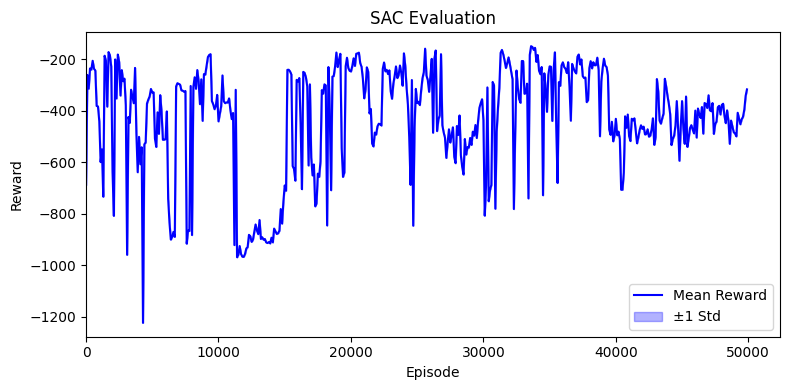

In [8]:
means = np.array(eval_means)
stds  = np.array(eval_stds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eval_episodes, means, color="blue", label="Mean Reward")
ax.fill_between(eval_episodes, means - stds, means + stds, alpha=0.3, color="blue", label="±1 Std")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_xlim(left=0)
ax.set_title("SAC Evaluation")
ax.legend()
plt.tight_layout()
plt.show()

c:\Users\mccha\OneDrive\Desktop\control algorithms\train\..\models\SAC.py:217: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  state = torch.tensor([observation], dtype=torch.float32)


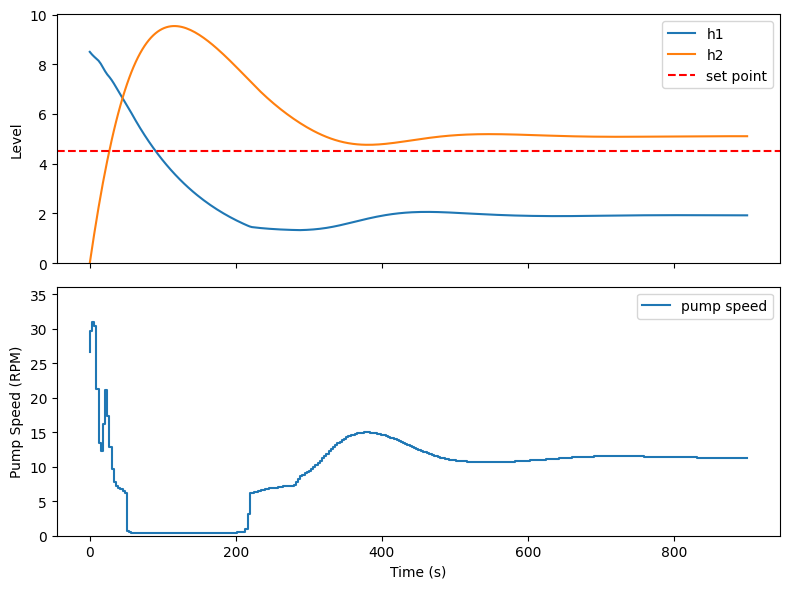

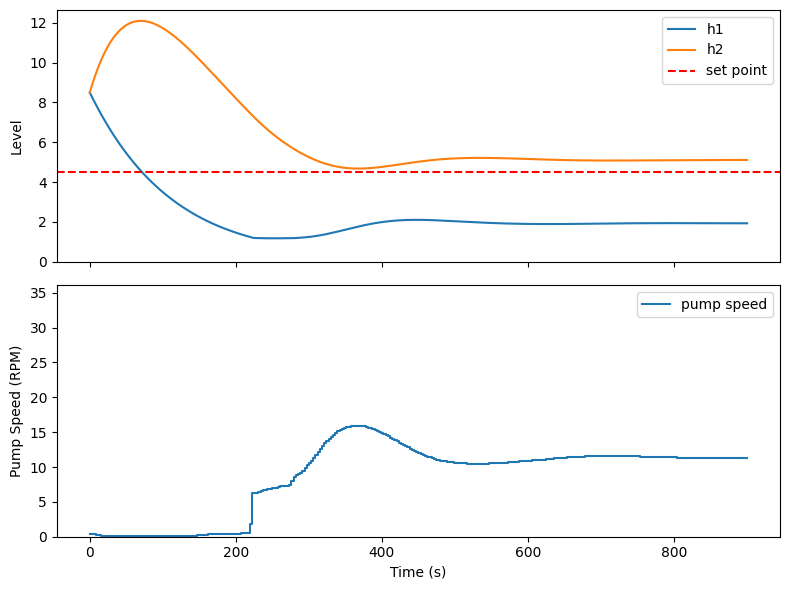

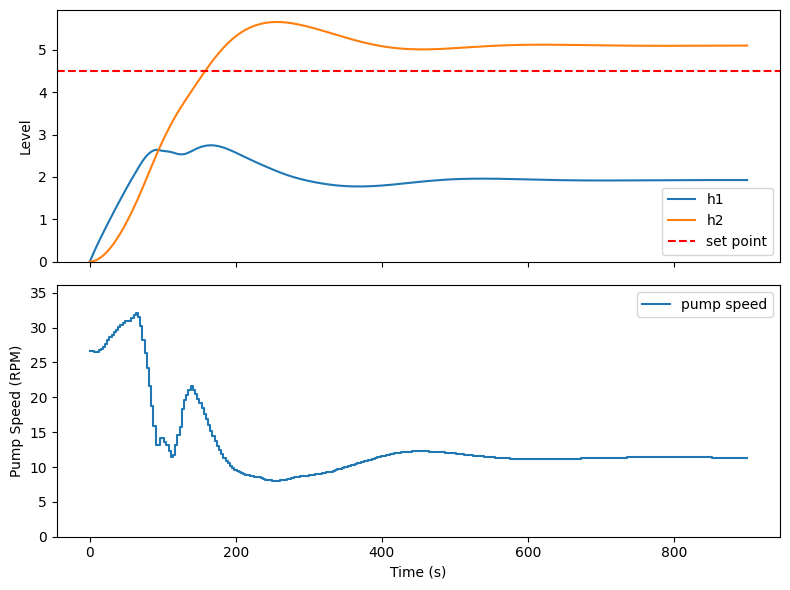

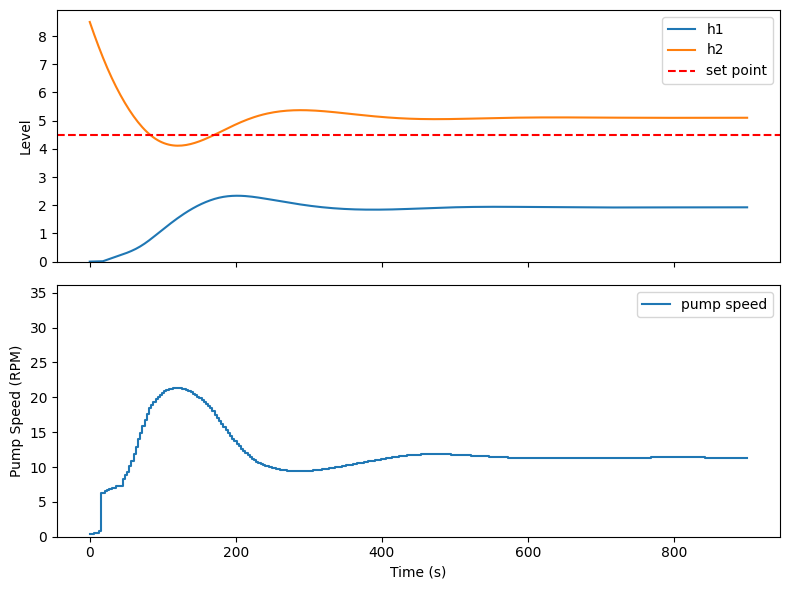

In [9]:
SET_POINT = 4.5
MAX_H = 8.5
INITIAL_STATE = np.array([[8.5, 8.5, 0, 0], 
                          [0, 8.5, 0, 8.5]])

agent.mode_eval()

with open(r"..\parameters\state_space_param.pickle", "rb") as f:
    param = pickle.load(f)
A, B, C, D = param["A"], param["B"], param["C"], param["D"]

environment = StateSpaceModel(pred_x0=False)

with torch.no_grad():
    for i in range(INITIAL_STATE.shape[1]):
        h1_trajectory = []
        h2_trajectory = []
        action_trajectory = []
        time_trajectory = []
        xk = INITIAL_STATE[:,i]
        h1_trajectory.append(xk[0].item())
        h2_trajectory.append(xk[1].item())
        for j in range(MAX_ITER_PER_EPISODE):
            input_state = np.array((xk[1].item(), SET_POINT))
            norm_state = input_state/MAX_H
            action = agent.choose_action(norm_state, distributional=False)
            action_trajectory.append(action)
            time_trajectory.append(j*DT)
            xk, _ = environment.step_pred(A, B, C, D, xk, action, dt=DT)
            h1_trajectory.append(xk[0].item())
            h2_trajectory.append(xk[1].item())
        time_trajectory.append((j+1)*DT)
        input_state = np.array((xk[1].item(), SET_POINT))
        norm_state = input_state/MAX_H
        action = agent.choose_action(norm_state, distributional=False)
        action_trajectory.append(action)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

        ax1.plot(time_trajectory, h1_trajectory, label="h1")
        ax1.plot(time_trajectory, h2_trajectory, label="h2")
        ax1.axhline(y=SET_POINT, label="set point", ls="--", color="red")  # cleaner for constant lines
        ax1.set_ylabel("Level")
        ax1.set_ylim(bottom=0)
        ax1.legend()

        ax2.step(time_trajectory, action_trajectory, label="pump speed")
        ax2.set_ylabel("Pump Speed (RPM)")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylim(bottom=0, top=36.1)
        ax2.legend()

        plt.tight_layout()
        plt.show()

In [10]:
torch.save(agent.actor.state_dict(), r"..\parameters\SAC.pt")

Additional training run

In [7]:
MAX_EPISODE = 25000
MAX_TIME_PER_EPISODE = 60*15
DT = 3
MAX_ITER_PER_EPISODE = int(MAX_TIME_PER_EPISODE/DT) # This should be 300

In [6]:
agent = SoftActorCritic(v_net_arg, q_net_arg, actor_net_arg, replay_capa)
agent.actor.load_state_dict(torch.load(r"..\parameters\SAC.pt"))
print(agent.actor, agent.critic_1, agent.value)

ActorNetwork(
  (backbone): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (mu_net): Linear(in_features=128, out_features=1, bias=True)
  (log_std_net): Linear(in_features=128, out_features=1, bias=True)
) QNetwork(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
) VNetwork(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [9]:
UPDATE_EVERY = 20
UPDATE_TIMES = 10
n = 0
env = environment()
eval_episodes = []
eval_means    = []
eval_stds     = []

for ep in tqdm(range(MAX_EPISODE)):
    state = env.reset()
    done = False
    
    for _ in range(MAX_ITER_PER_EPISODE):
        action = agent.choose_action(state, distributional=True)
        next_state, reward, terminated = env.step(action, dt=DT)
        agent.store_transition(state, action, reward, next_state, terminated)

        n += 1
        if n % UPDATE_EVERY == 0:
            for __ in range(UPDATE_TIMES):
                agent.update()

        state = next_state
        if terminated:
            break
    
    if ep%100 == 0:
        rewards = evaluate(agent)
        eval_episodes.append(ep)
        eval_means.append(np.mean(rewards))
        eval_stds.append(np.std(rewards))

100%|██████████| 25000/25000 [6:42:12<00:00,  1.04it/s]  


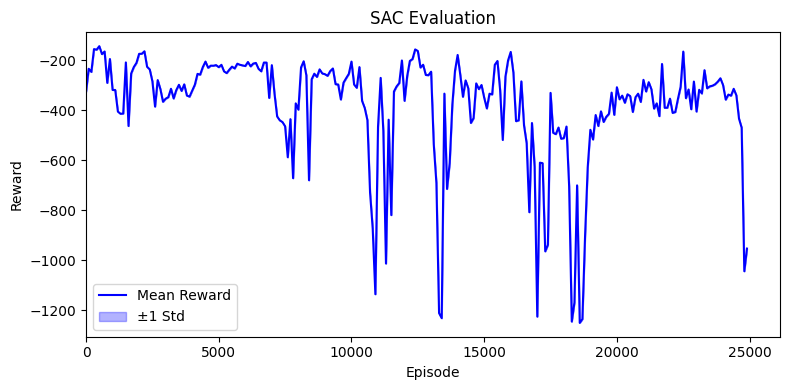

In [10]:
means = np.array(eval_means)
stds  = np.array(eval_stds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eval_episodes, means, color="blue", label="Mean Reward")
ax.fill_between(eval_episodes, means - stds, means + stds, alpha=0.3, color="blue", label="±1 Std")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_xlim(left=0)
ax.set_title("SAC Evaluation")
ax.legend()
plt.tight_layout()
plt.show()

c:\Users\mccha\OneDrive\Desktop\control algorithms\train\..\models\SAC.py:217: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  state = torch.tensor([observation], dtype=torch.float32)


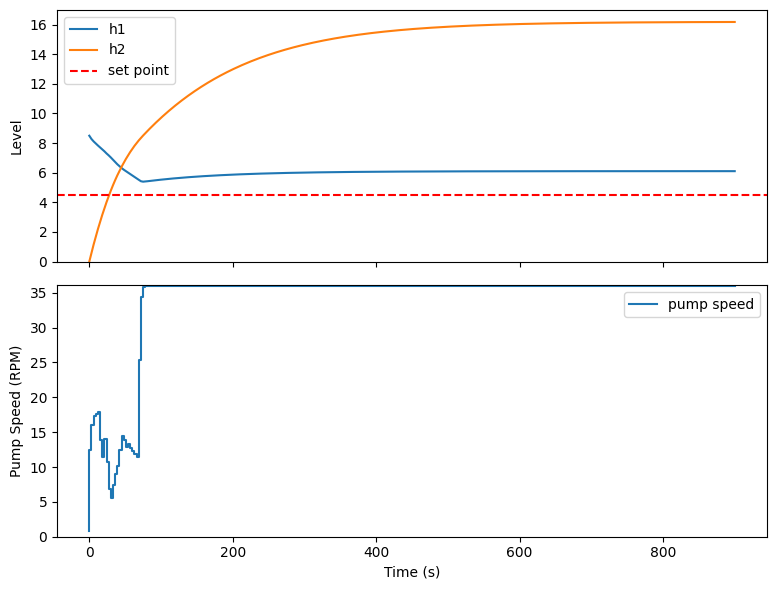

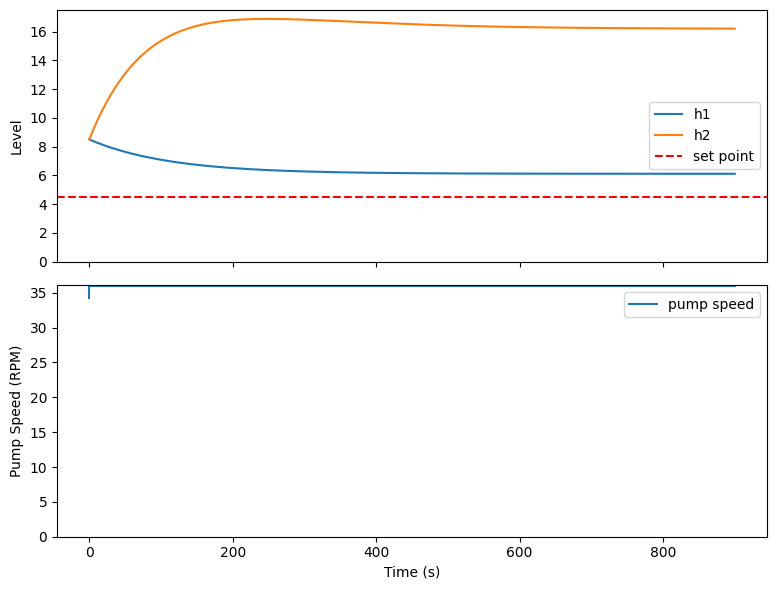

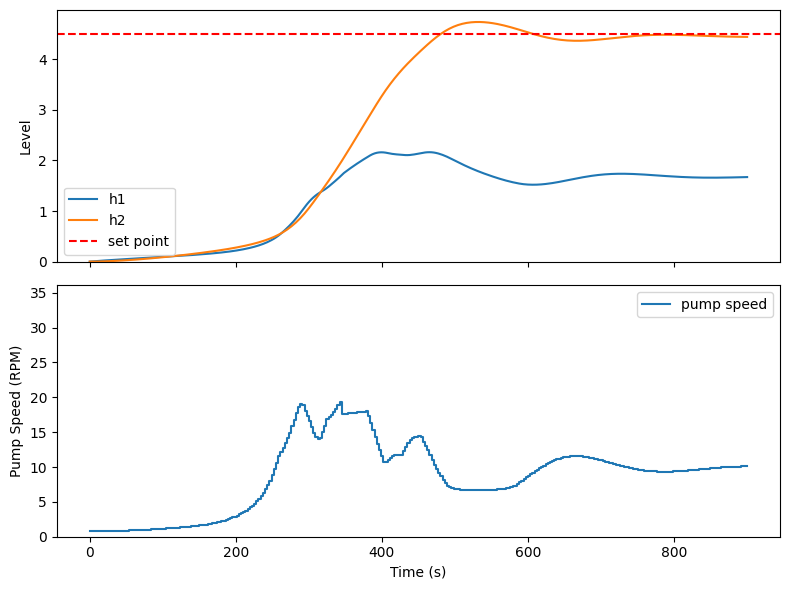

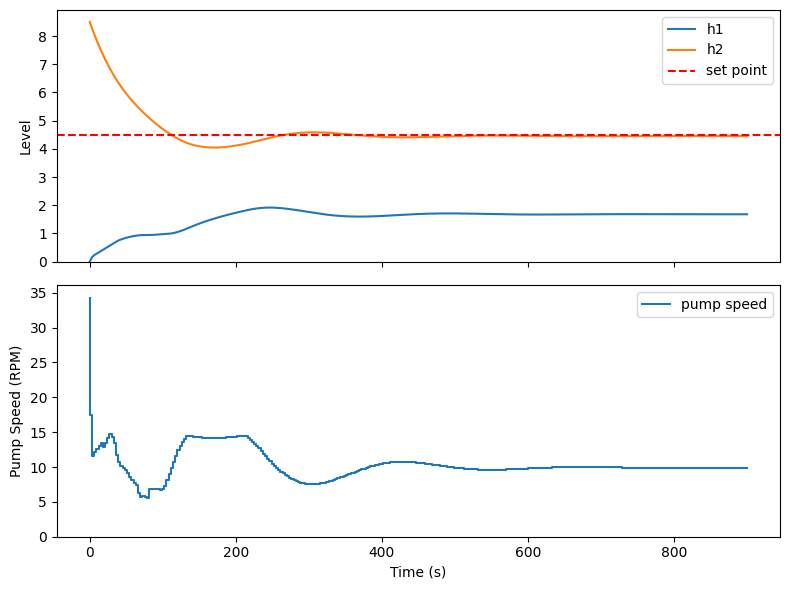

In [11]:
SET_POINT = 4.5
MAX_H = 8.5
INITIAL_STATE = np.array([[8.5, 8.5, 0, 0], 
                          [0, 8.5, 0, 8.5]])

agent.mode_eval()

with open(r"..\parameters\state_space_param.pickle", "rb") as f:
    param = pickle.load(f)
A, B, C, D = param["A"], param["B"], param["C"], param["D"]

environment = StateSpaceModel(pred_x0=False)

with torch.no_grad():
    for i in range(INITIAL_STATE.shape[1]):
        h1_trajectory = []
        h2_trajectory = []
        action_trajectory = []
        time_trajectory = []
        xk = INITIAL_STATE[:,i]
        h1_trajectory.append(xk[0].item())
        h2_trajectory.append(xk[1].item())
        for j in range(MAX_ITER_PER_EPISODE):
            input_state = np.array((xk[1].item(), SET_POINT))
            norm_state = input_state/MAX_H
            action = agent.choose_action(norm_state, distributional=False)
            action_trajectory.append(action)
            time_trajectory.append(j*DT)
            xk, _ = environment.step_pred(A, B, C, D, xk, action, dt=DT)
            h1_trajectory.append(xk[0].item())
            h2_trajectory.append(xk[1].item())
        time_trajectory.append((j+1)*DT)
        input_state = np.array((xk[1].item(), SET_POINT))
        norm_state = input_state/MAX_H
        action = agent.choose_action(norm_state, distributional=False)
        action_trajectory.append(action)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

        ax1.plot(time_trajectory, h1_trajectory, label="h1")
        ax1.plot(time_trajectory, h2_trajectory, label="h2")
        ax1.axhline(y=SET_POINT, label="set point", ls="--", color="red")  # cleaner for constant lines
        ax1.set_ylabel("Level")
        ax1.set_ylim(bottom=0)
        ax1.legend()

        ax2.step(time_trajectory, action_trajectory, label="pump speed")
        ax2.set_ylabel("Pump Speed (RPM)")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylim(bottom=0, top=36.1)
        ax2.legend()

        plt.tight_layout()
        plt.show()